# Step 1: Render PDF Page Images (`empty-core-3.pdf`)

This notebook extracts 300 DPI page images from `empty-core-3.pdf` using PyMuPDF (`fitz`).


In [1]:
# Setup environment & imports
import os
import sys
from IPython.display import Image, display

backend_path = r"c:\Users\hamza\Desktop\S2S\backend"
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)
project_root = r"c:\Users\hamza\Desktop\S2S"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import fitz  # PyMuPDF
print("✅ Python environment ready!")
print("   - Loaded backend from:", backend_path)
print("   - PyMuPDF doc:", fitz.__doc__)

✅ Python environment ready!
   - Loaded backend from: c:\Users\hamza\Desktop\S2S\backend
   - PyMuPDF doc: PyMuPDF 1.28.0: Python bindings for the MuPDF 1.29.0 library.
Python 3.14 running on win32 (64-bit).



Loaded empty-core-3.pdf successfully. Total pages: 2
Rendered Page 1: empty_core_page_01.png (2480x3509 px)
Rendered Page 2: empty_core_page_02.png (2480x3509 px)


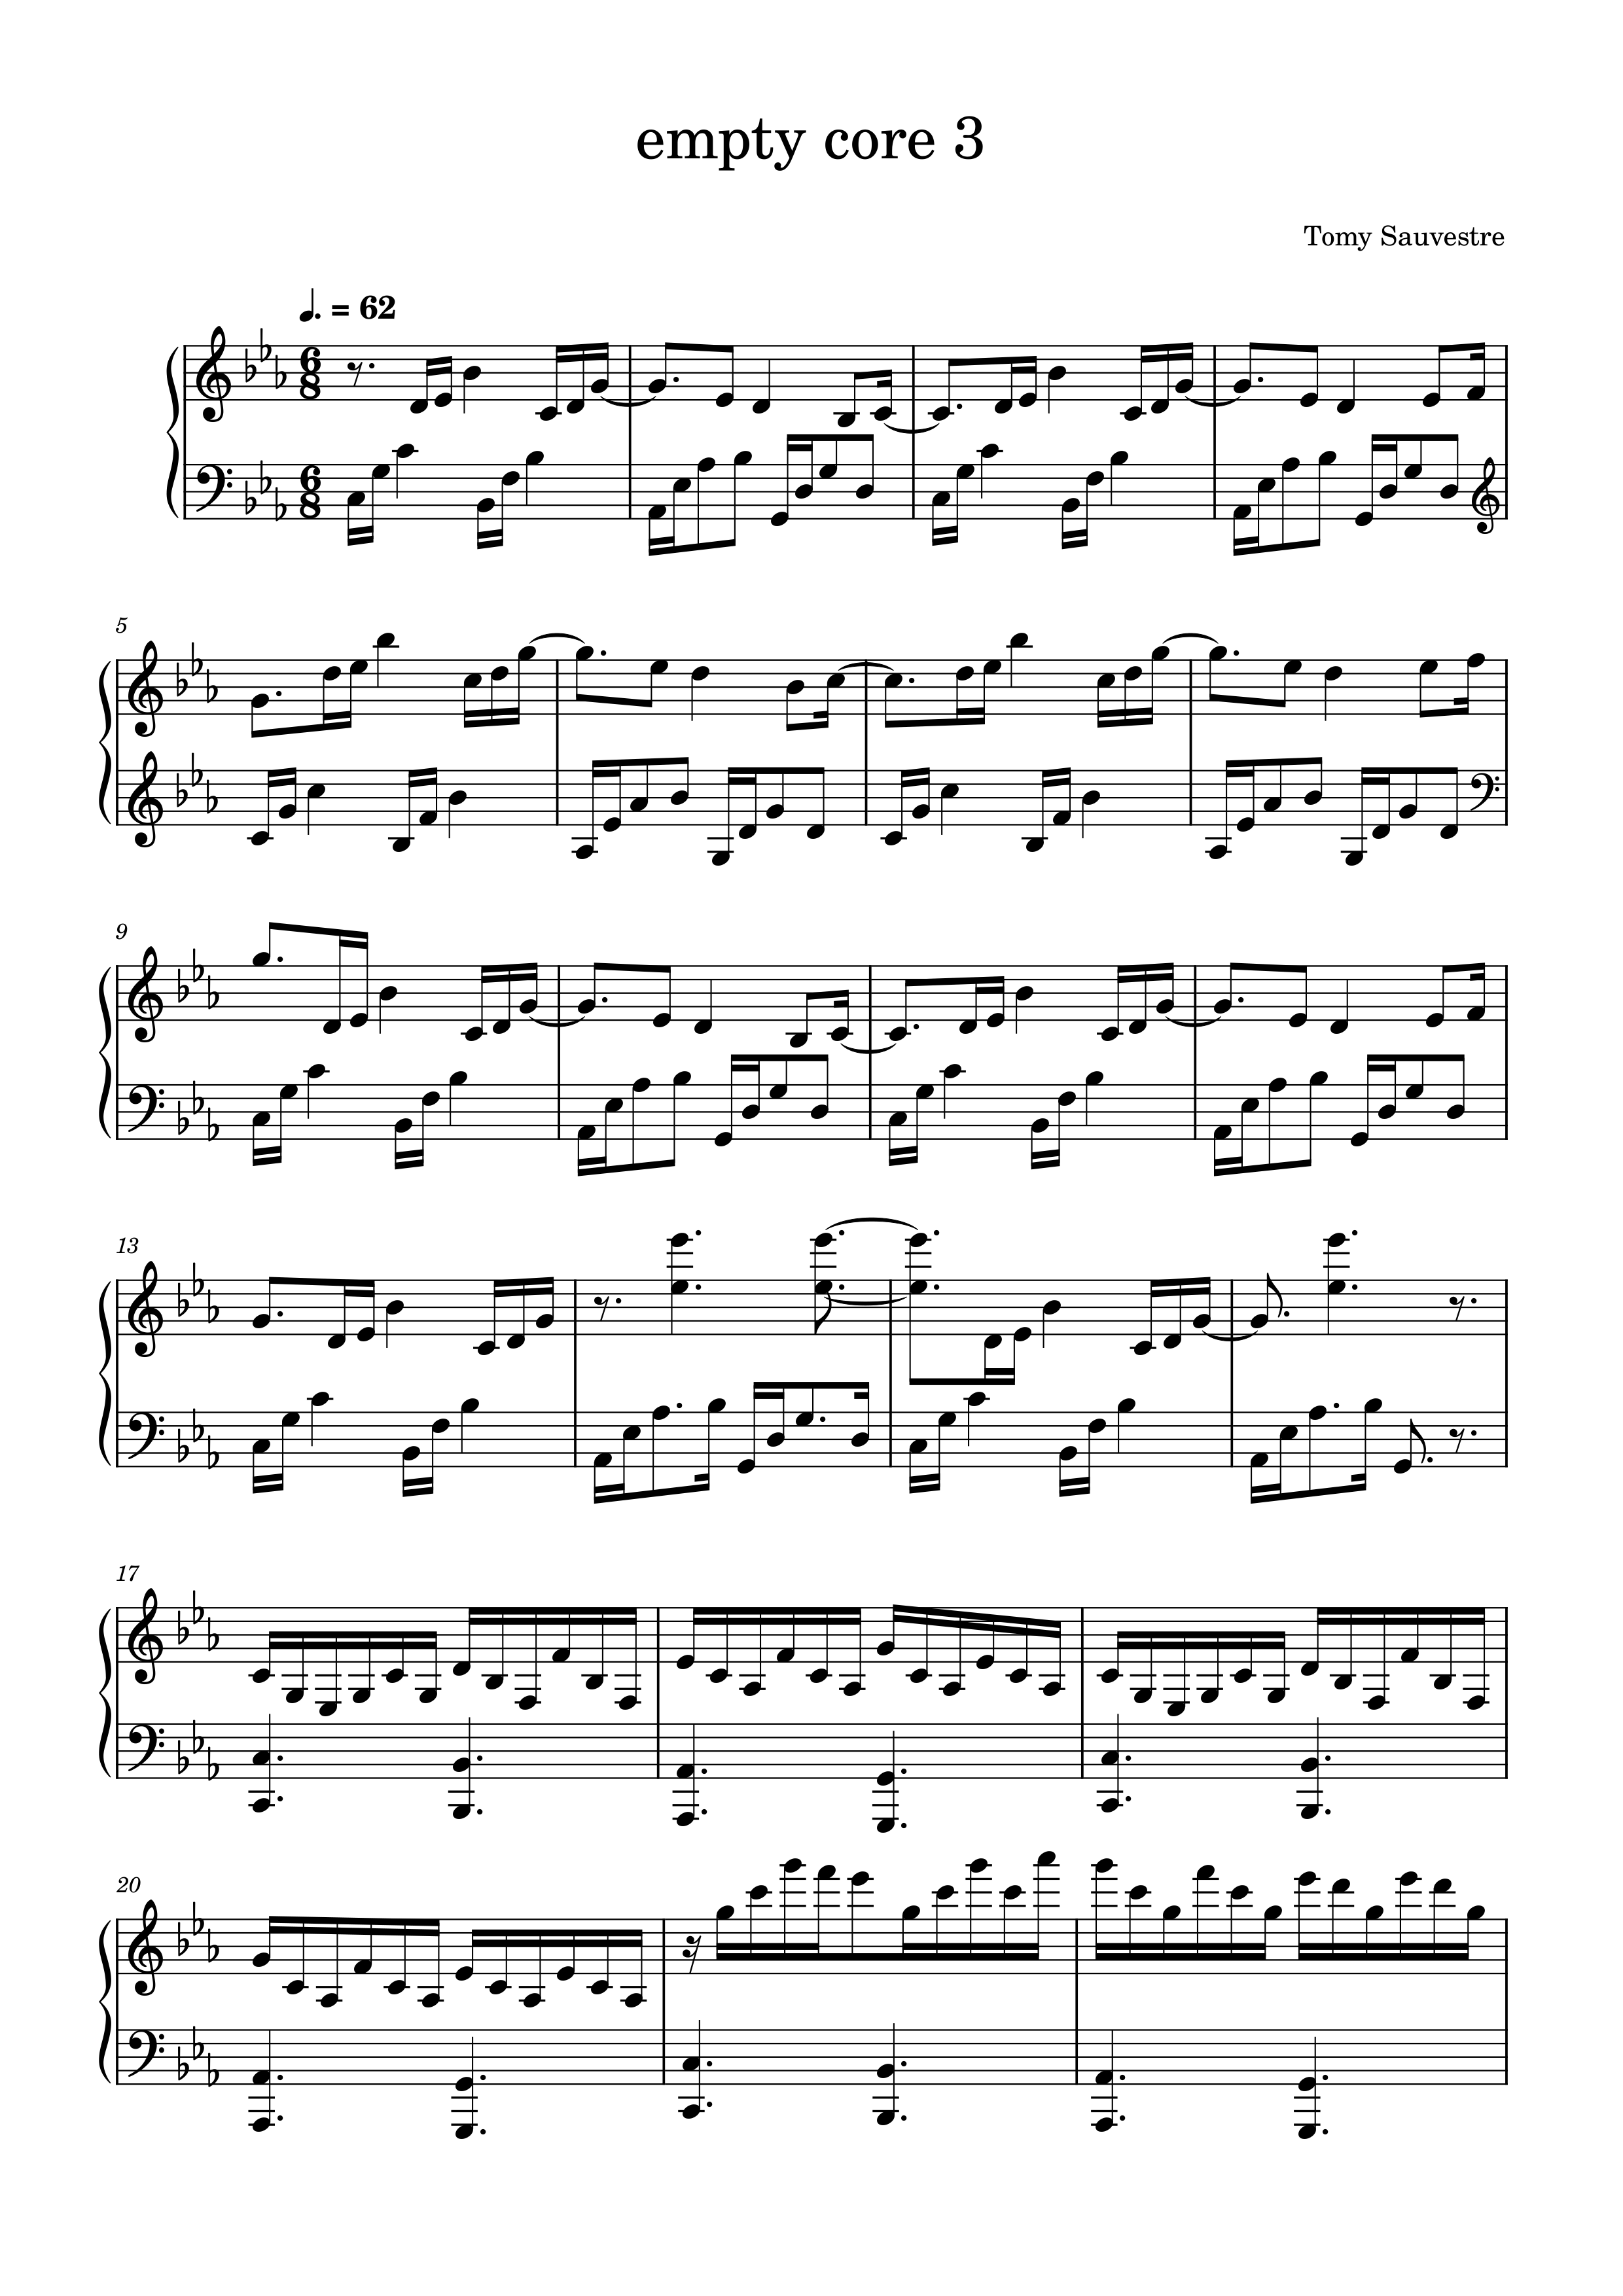

In [2]:
# Render empty-core-3.pdf pages to 300 DPI PNG images
pdf_filename = "empty-core-3.pdf"
if not os.path.exists(pdf_filename):
    raise FileNotFoundError(f"Target PDF '{pdf_filename}' not found in jupyter folder.")

doc = fitz.open(pdf_filename)
print("Loaded empty-core-3.pdf successfully. Total pages:", len(doc))

rendered_images = []
zoom = 300 / 72.0  # 300 DPI rendering
mat = fitz.Matrix(zoom, zoom)

for idx, page in enumerate(doc):
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img_path = f"empty_core_page_{idx+1:02d}.png"
    pix.save(img_path)
    rendered_images.append(img_path)
    print(f"Rendered Page {idx+1}: {img_path} ({pix.width}x{pix.height} px)")

doc.close()

# Display first page image inline
display(Image(filename=rendered_images[0], width=500))